# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1, 2026–2027 — Major Project**

### Project Objective
To analyze agricultural data across **Kharif, Rabi and Zaid** seasons and identify meaningful patterns in environmental conditions, resource usage, crop yield, production, profitability, irrigation, and disease/pest risk.

### Analytical Approach
This notebook follows a complete data-analytics workflow:
1. Dataset understanding
2. Data quality checks and cleaning
3. Exploratory analysis
4. Seasonal comparisons
5. Statistical testing
6. Economic and resource analysis
7. Crop, state and irrigation comparisons
8. Correlation and relationship analysis
9. Key findings and recommendations
10. Limitations and final conclusion

> **Important:** Findings are interpreted as associations observed in the dataset. Statistical relationships do not by themselves prove causation.

In [1]:
# 1.1 Import required libraries
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

warnings.filterwarnings('ignore', category=FutureWarning)

# Professional notebook styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#4C956C', 'Rabi': '#D68C45', 'Zaid': '#3B6E8F'}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Understanding

In [2]:
# Load the supplied dataset
DATA_FILE = 'seasonal_agriculture_performance_dataset.csv'

if not os.path.exists(DATA_FILE):
    try:
        from google.colab import files
        print(f"'{DATA_FILE}' was not found. Please upload the CSV file.")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('No dataset was uploaded.')
        DATA_FILE = next(iter(uploaded.keys()))
    except ImportError:
        raise FileNotFoundError(
            f"'{DATA_FILE}' was not found. Upload the supplied CSV to the notebook working directory."
        )

df_raw = pd.read_csv(DATA_FILE)
df = df_raw.copy()

print('Dataset loaded successfully.')
print('File:', DATA_FILE)
print('Shape:', df.shape)
df.head()

Dataset loaded successfully.
File: seasonal_agriculture_performance_dataset.csv
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [4]:
print("Number of unique States   :", df['State'].nunique())
print("Number of unique Districts:", df['District'].nunique())
print("Number of unique Crops    :", df['Crop'].nunique())
print("Irrigation Methods        :", df['Irrigation_Method'].unique().tolist())
print("\nRecords per Season:")
print(df['Season'].value_counts().reindex(SEASON_ORDER))


Number of unique States   : 8
Number of unique Districts: 10
Number of unique Crops    : 8
Irrigation Methods        : ['Drip', 'Flood', 'Rainfed', 'Sprinkler']

Records per Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 1.1 Analytical Questions

The project brief asks students to develop specific questions after exploring the dataset. The analysis in this notebook focuses on:

1. How does agricultural yield vary across Kharif, Rabi and Zaid?
2. How do rainfall, temperature, humidity and soil moisture differ across seasons?
3. How do fertilizer, nutrient, pesticide and water usage vary by season?
4. Which season has the strongest revenue, profit and profit margin?
5. What proportion of farms operate at a loss in each season?
6. Is the observed seasonal difference in yield statistically significant?
7. How do crop-level and state-level patterns vary across seasons?
8. How do irrigation methods compare within each season?
9. Which relationships between variables are visible in the data, while avoiding misleading interpretations from mathematically derived variables?
10. What evidence-based recommendations can be made for seasonal agricultural planning?

## 2. Data Cleaning & Preparation

Before analysis, the dataset is checked for duplicate records, missing values and inconsistent/extreme values.

In [6]:
# 2.1 Duplicate records
print("Duplicate rows:", df.duplicated().sum())

# 2.2 Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing)
print("\nPercentage missing:")
print((missing / len(df) * 100).round(2))


Duplicate rows: 0

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage missing:
Rainfall_mm         1.20
Soil_Moisture_pct   1.00
Yield_Tonnes_Ha     0.80
dtype: float64


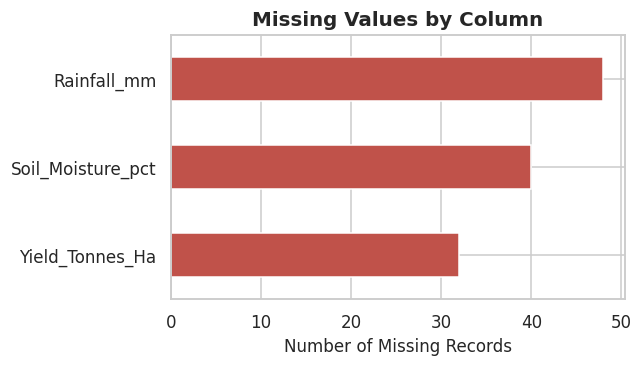

In [7]:
# 2.3 Visualise missing values
fig, ax = plt.subplots(figsize=(6, 3.5))
missing.sort_values().plot(kind='barh', color='#C0524A', ax=ax)
ax.set_title('Missing Values by Column')
ax.set_xlabel('Number of Missing Records')
plt.tight_layout()
plt.show()


In [8]:
# 2.4 Handling missing values
# Missing Rainfall, Soil Moisture and Yield values are imputed using the median
# of the same Season + Crop group. If a group median is unavailable, the
# overall column median is used as a fallback.

imputation_report = {}
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    before = df[col].isna().sum()
    df[col] = df.groupby(['Season', 'Crop'], observed=False)[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())
    after = df[col].isna().sum()
    imputation_report[col] = {'Missing before': before, 'Missing after': after}

pd.DataFrame(imputation_report).T

,Missing before,Missing after
Rainfall_mm,48,0
Soil_Moisture_pct,40,0
Yield_Tonnes_Ha,32,0


In [9]:
# 2.5 Sanity checks for invalid / impossible values
checks = {
    'Negative Rainfall'      : (df['Rainfall_mm'] < 0).sum(),
    'Humidity out of 0-100'  : (~df['Humidity_pct'].between(0, 100)).sum(),
    'Soil pH out of 0-14'    : (~df['Soil_pH'].between(0, 14)).sum(),
    'Negative Yield'         : (df['Yield_Tonnes_Ha'] < 0).sum(),
    'Negative Farm Area'     : (df['Farm_Area_Hectares'] < 0).sum(),
    'Negative Cost/Revenue'  : ((df['Total_Cost_INR'] < 0) | (df['Revenue_INR'] < 0)).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v} record(s)")


Negative Rainfall: 0 record(s)
Humidity out of 0-100: 0 record(s)
Soil pH out of 0-14: 0 record(s)
Negative Yield: 0 record(s)
Negative Farm Area: 0 record(s)
Negative Cost/Revenue: 0 record(s)


In [10]:
# 2.6 Note on Sugarcane yield scale
# Sugarcane is harvested in tonnes/hectare at a scale ~20-30x higher than other crops
# (a real agronomic characteristic, not a data error). It is kept in the dataset but
# treated separately in yield comparisons to avoid distorting cross-crop averages.
print(df.groupby('Crop')['Yield_Tonnes_Ha'].agg(['mean', 'median', 'max']).round(2))


           mean  median    max
Crop                          
Chilli     1.54    1.56   3.90
Cotton     1.23    1.23   2.90
Groundnut  1.32    1.38   3.02
Maize      2.72    2.84   6.08
Pulses     0.92    0.94   2.09
Rice       2.44    2.46   5.70
Sugarcane 46.93   47.88 101.44
Wheat      2.11    2.23   4.56


In [11]:
# Ensure Season follows a logical order in all tables and plots
df['Season'] = pd.Categorical(df['Season'], categories=SEASON_ORDER, ordered=True)

print('Data cleaning complete.')
print('Final shape:', df.shape)
print('Remaining missing values:', int(df.isna().sum().sum()))

Data cleaning complete.
Final shape: (4000, 28)
Remaining missing values: 0


## 3. Season-wise Farm Distribution

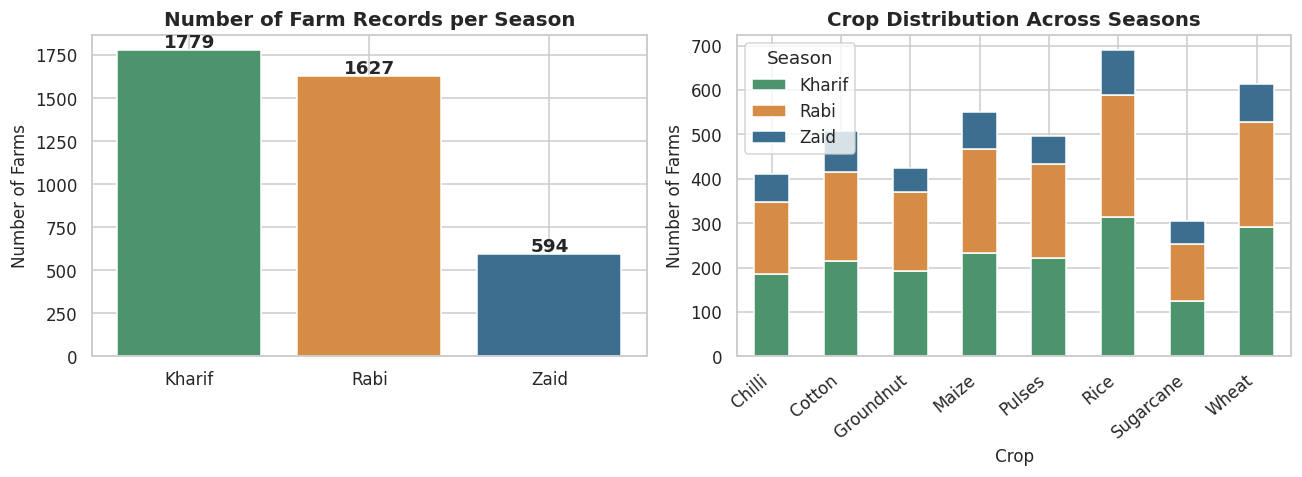

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)
axes[0].bar(season_counts.index, season_counts.values,
            color=[SEASON_COLORS[s] for s in season_counts.index])
axes[0].set_title('Number of Farm Records per Season')
axes[0].set_ylabel('Number of Farms')
for i, v in enumerate(season_counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

crop_season = pd.crosstab(df['Crop'], df['Season'])
crop_season.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[1].set_title('Crop Distribution Across Seasons')
axes[1].set_ylabel('Number of Farms')
axes[1].legend(title='Season')
plt.setp(axes[1].get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.show()


**Observation:** Kharif contains the largest number of records, followed by Rabi and Zaid. This describes the composition of the supplied dataset; it should not be interpreted as the actual number of farms in India. (~1,779), followed by Rabi (~1,627) and Zaid (~594). Zaid being the short summer season naturally has fewer farms under cultivation, which is consistent with real agricultural practice in India.

## 4. Environmental Conditions Across Seasons

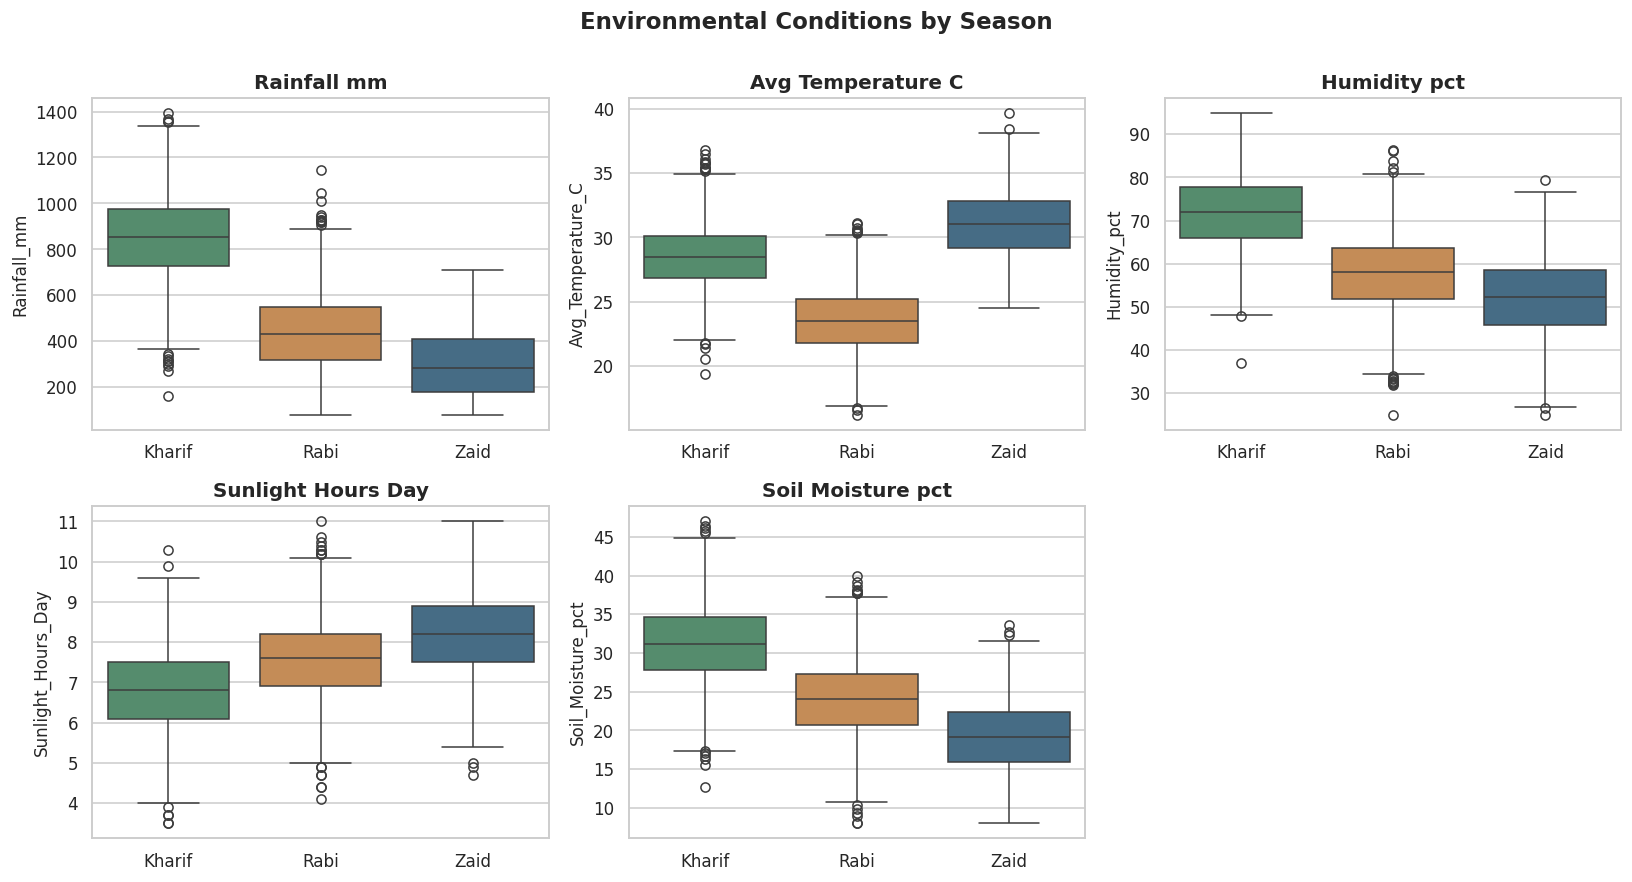

In [13]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER,
                palette=SEASON_COLORS, ax=axes[i])
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('')
axes[-1].axis('off')
plt.suptitle('Environmental Conditions by Season', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


In [14]:
df.groupby('Season')[env_cols].mean().round(2).reindex(SEASON_ORDER)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


**Observation:** The supplied data shows clear seasonal differences in environmental conditions: Kharif has the highest average rainfall and humidity, while Zaid has the highest average temperature and sunlight hours and the lowest average rainfall. Soil moisture follows a similar seasonal pattern. and humidity (monsoon season), Zaid records the highest average temperature and sunlight hours with the lowest rainfall (dry summer season), and Rabi shows moderate, cooler and drier winter-season conditions. Soil moisture broadly tracks the rainfall pattern.

## 5. Resource Usage Across Seasons

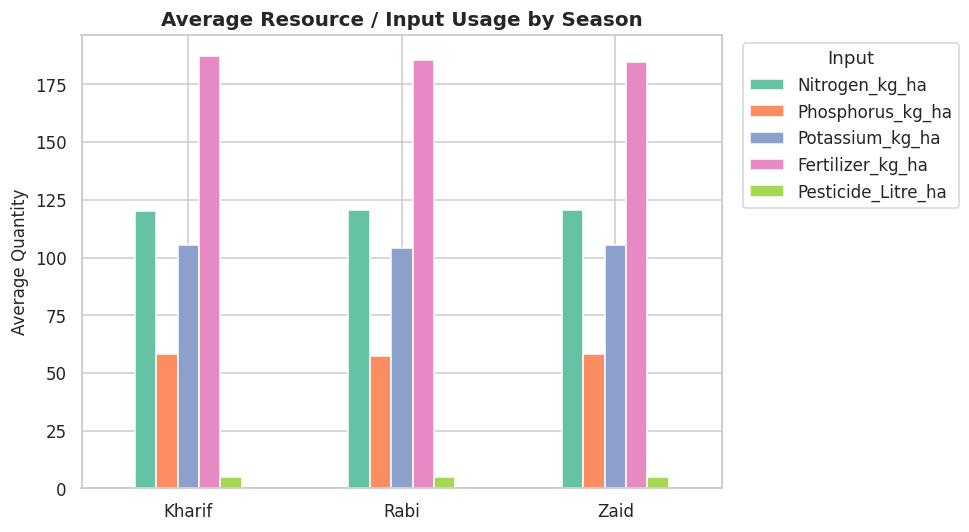

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08
Rabi,120.40,57.31,103.93,185.41,5.02
Zaid,120.53,58.13,105.42,184.64,5.17


In [15]:
resource_cols = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']

season_resource = df.groupby('Season')[resource_cols].mean().reindex(SEASON_ORDER)

fig, ax = plt.subplots(figsize=(9, 5))
season_resource.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(resource_cols)))
ax.set_title('Average Resource / Input Usage by Season')
ax.set_ylabel('Average Quantity')
ax.set_xlabel('')
plt.xticks(rotation=0)
ax.legend(title='Input', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

season_resource.round(2)


**Observation:** Average fertilizer and NPK usage are relatively close across the three seasons. Pesticide usage varies only modestly, so the dataset does not support a strong claim that pesticide use simply increases with humidity. (Nitrogen, Phosphorus, Potassium) usage stay fairly close across the three seasons, with only mild variation. Pesticide use is marginally higher in seasons with higher humidity, consistent with greater pest/disease pressure in moist conditions.

## 6. Yield & Production Performance Across Seasons

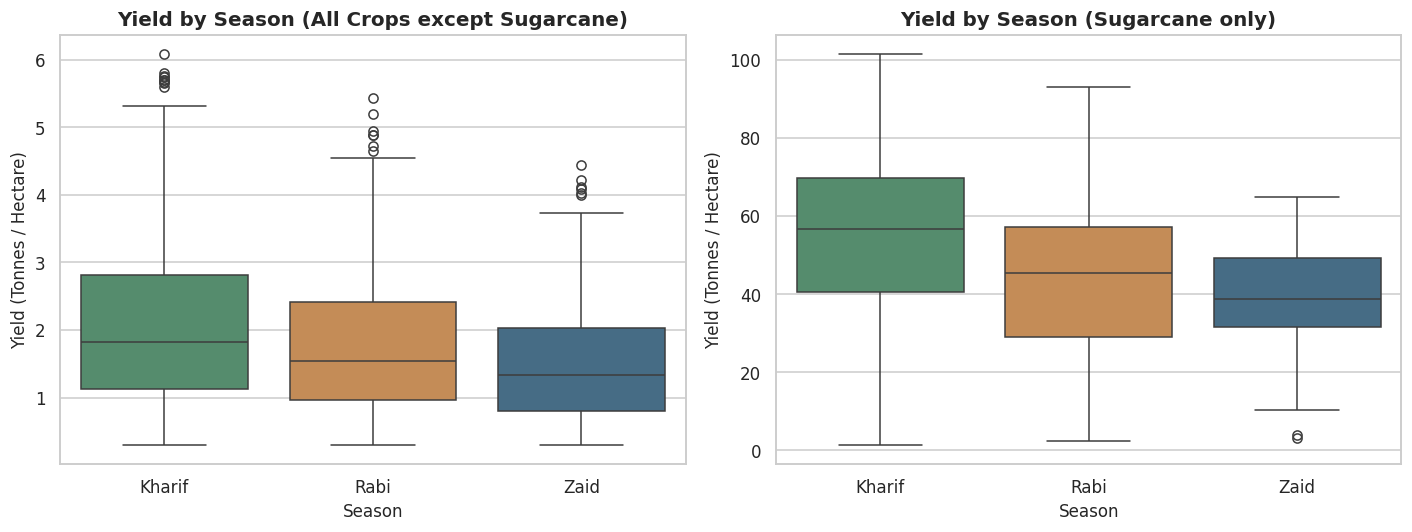

In [16]:
# Yield is analysed excluding Sugarcane (different scale) and separately for Sugarcane
non_sugar = df[df['Crop'] != 'Sugarcane']
sugar = df[df['Crop'] == 'Sugarcane']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=non_sugar, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            palette=SEASON_COLORS, ax=axes[0])
axes[0].set_title('Yield by Season (All Crops except Sugarcane)')
axes[0].set_ylabel('Yield (Tonnes / Hectare)')

sns.boxplot(data=sugar, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            palette=SEASON_COLORS, ax=axes[1])
axes[1].set_title('Yield by Season (Sugarcane only)')
axes[1].set_ylabel('Yield (Tonnes / Hectare)')

plt.tight_layout()
plt.show()


In [17]:
print("Mean Yield (t/ha) by Season, excluding Sugarcane:")
print(non_sugar.groupby('Season')['Yield_Tonnes_Ha'].mean().round(2).reindex(SEASON_ORDER))
print("\nMean Yield (t/ha) by Season, Sugarcane only:")
print(sugar.groupby('Season')['Yield_Tonnes_Ha'].mean().round(2).reindex(SEASON_ORDER))


Mean Yield (t/ha) by Season, excluding Sugarcane:
Season
Kharif   2.02
Rabi     1.75
Zaid     1.46
Name: Yield_Tonnes_Ha, dtype: float64

Mean Yield (t/ha) by Season, Sugarcane only:
Season
Kharif   53.46
Rabi     43.96
Zaid     38.42
Name: Yield_Tonnes_Ha, dtype: float64


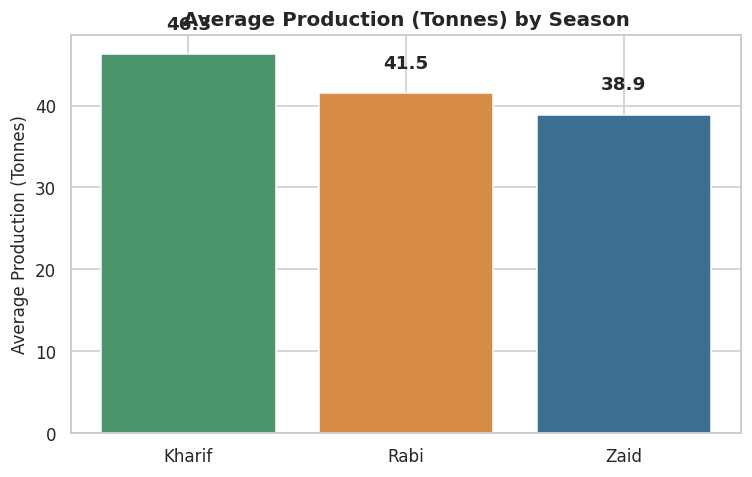

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
prod = df.groupby('Season')['Production_Tonnes'].mean().reindex(SEASON_ORDER)
bars = ax.bar(prod.index, prod.values, color=[SEASON_COLORS[s] for s in prod.index])
ax.set_title('Average Production (Tonnes) by Season')
ax.set_ylabel('Average Production (Tonnes)')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, f"{b.get_height():.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Kharif has the highest mean yield in the non-Sugarcane comparison, followed by Rabi and Zaid. This is an observed seasonal pattern in the dataset; the analysis does not establish that rainfall alone caused the difference. among non-sugarcane crops, likely benefiting from monsoon rainfall and higher soil moisture. Rabi yields are close behind. Zaid, with limited water availability, shows comparatively lower yield despite higher sunlight, unless irrigation compensates for the rainfall deficit.

## 7. Statistical Testing — Is the Seasonal Difference in Yield Significant?

A one-way **ANOVA** (with a Kruskal–Wallis non-parametric check) is used to test whether the mean yield genuinely differs across the three seasons, or whether the difference could be due to random variation.

**Hypotheses**
- H0 (Null): Mean yield is the same across Kharif, Rabi and Zaid seasons.
- H1 (Alternative): At least one season has a significantly different mean yield.

In [19]:
# 7.1 Statistical tests for seasonal yield differences
# Use non-Sugarcane yield for the cross-crop seasonal comparison because
# Sugarcane is measured on a much larger yield scale in this dataset.
groups = [non_sugar.loc[non_sugar['Season'] == s, 'Yield_Tonnes_Ha'].dropna() for s in SEASON_ORDER]

f_stat, p_val = stats.f_oneway(*groups)
h_stat, p_val_kw = stats.kruskal(*groups)

# Eta-squared: proportion of total variation associated with season in this one-way ANOVA.
grand_mean = non_sugar['Yield_Tonnes_Ha'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((non_sugar['Yield_Tonnes_Ha'] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print(f'One-way ANOVA       -> F = {f_stat:.3f}, p-value = {p_val:.6g}')
print(f'Kruskal-Wallis      -> H = {h_stat:.3f}, p-value = {p_val_kw:.6g}')
print(f'Eta-squared (η²)    -> {eta_sq:.4f} ({eta_sq*100:.2f}% of yield variation associated with season)')

if p_val < 0.05:
    print()
    print('Conclusion: Reject H0 at α = 0.05. The observed mean yield differs significantly across seasons.')
else:
    print()
    print('Conclusion: Fail to reject H0 at α = 0.05.')

print('Interpretation note: statistical significance shows a difference in the observed groups; it does not establish causation.')

One-way ANOVA       -> F = 61.253, p-value = 6.7629e-27
Kruskal-Wallis      -> H = 100.504, p-value = 1.49895e-22
Eta-squared (η²)    -> 0.0321 (3.21% of yield variation associated with season)

Conclusion: Reject H0 at α = 0.05. The observed mean yield differs significantly across seasons.
Interpretation note: statistical significance shows a difference in the observed groups; it does not establish causation.


### 7.2 Post-hoc comparison (Tukey HSD)

ANOVA tells us whether at least one seasonal mean differs. Tukey HSD is used to identify which pairs of seasons differ while controlling the family-wise error rate.

In [20]:
tukey = pairwise_tukeyhsd(
    endog=non_sugar['Yield_Tonnes_Ha'],
    groups=non_sugar['Season'].astype(str),
    alpha=0.05
)
print(tukey)

# Compact pairwise result table for easy interpretation
try:
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    tukey_df
except Exception:
    pass

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Kharif   Rabi  -0.2683   0.0 -0.3577 -0.1789   True
Kharif   Zaid   -0.552   0.0  -0.676  -0.428   True
  Rabi   Zaid  -0.2837   0.0 -0.4093 -0.1581   True
---------------------------------------------------


In [21]:
# Same test repeated for Profit to check economic significance
profit_groups = [df[df['Season'] == s]['Profit_INR'] for s in SEASON_ORDER]
f_stat_p, p_val_p = stats.f_oneway(*profit_groups)
print(f"ANOVA on Profit ->  F-statistic = {f_stat_p:.3f},  p-value = {p_val_p:.5f}")
if p_val_p < 0.05:
    print("Result: Profit also differs significantly across seasons.")
else:
    print("Result: No statistically significant seasonal difference in profit.")


ANOVA on Profit ->  F-statistic = 34.292,  p-value = 0.00000
Result: Profit also differs significantly across seasons.


## 8. Economic Performance Across Seasons

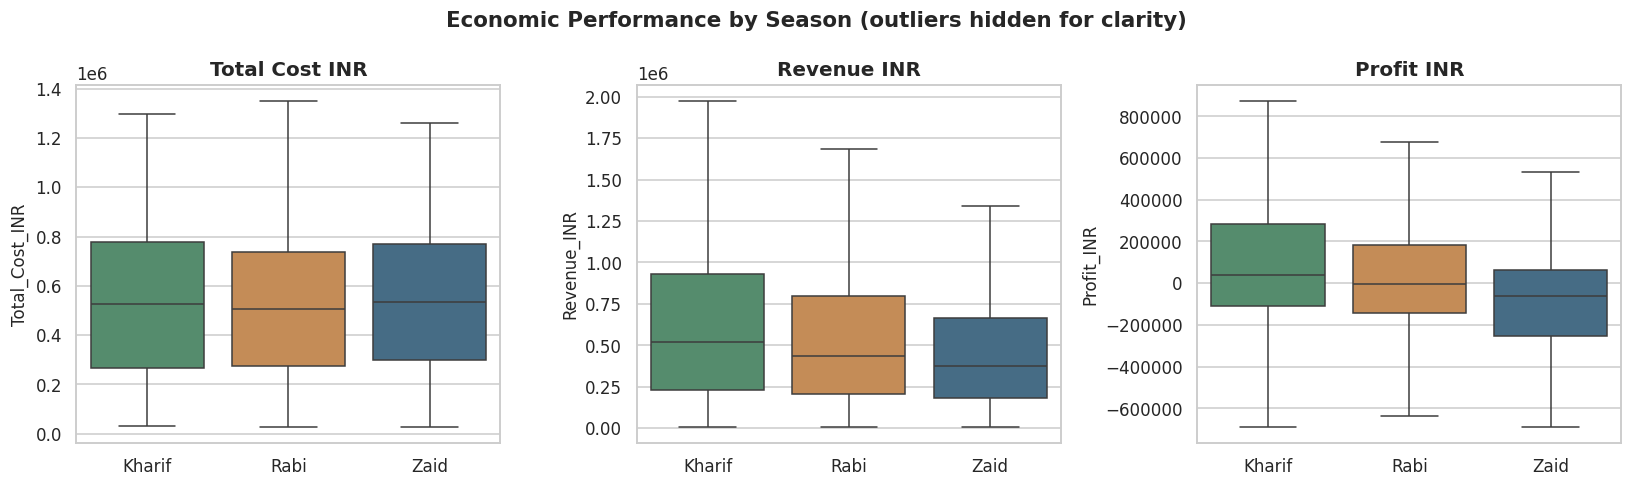

In [22]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, col in enumerate(econ_cols):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, palette=SEASON_COLORS,
                ax=axes[i], showfliers=False)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('')
plt.suptitle('Economic Performance by Season (outliers hidden for clarity)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [23]:
# Seasonal economic summary
season_econ = df.groupby('Season', observed=False)[econ_cols].mean().reindex(SEASON_ORDER)
season_econ['Profit_Margin_%'] = (season_econ['Profit_INR'] / season_econ['Revenue_INR'] * 100)
season_econ.round(2)

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_%
Season,,,,
Kharif,"531,804.41","710,719.06","178,914.65",25.17
Rabi,"513,836.58","601,526.05","87,689.47",14.58
Zaid,"543,976.73","519,171.90","-24,804.82",-4.78


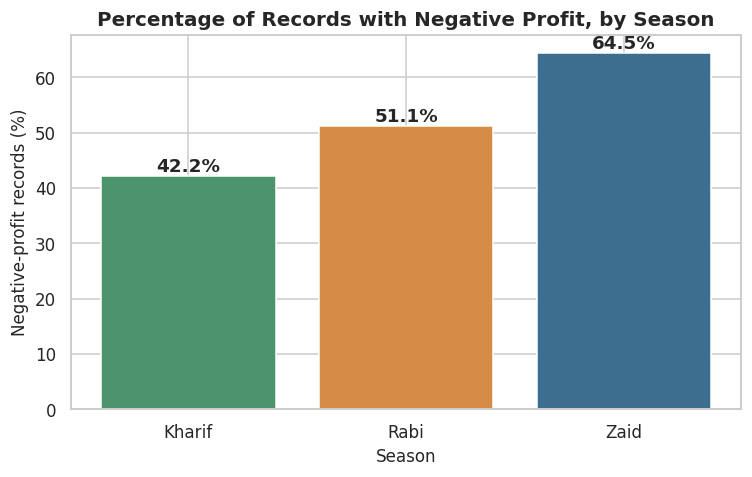

Season
Kharif   42.21
Rabi     51.14
Zaid     64.48
Name: Is_Loss, dtype: float64

In [24]:
# Share of records operating at a loss, by season
df['Is_Loss'] = df['Profit_INR'] < 0
loss_pct = (df.groupby('Season', observed=False)['Is_Loss'].mean().reindex(SEASON_ORDER) * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(loss_pct.index, loss_pct.values, color=[SEASON_COLORS[s] for s in loss_pct.index])
ax.set_title('Percentage of Records with Negative Profit, by Season')
ax.set_ylabel('Negative-profit records (%)')
ax.set_xlabel('Season')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8, f'{b.get_height():.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

loss_pct.round(2)

**Observation:** Negative profit occurs in all three seasons. The loss rate is lowest in Kharif and highest in Zaid, showing that seasonal differences are visible not only in production measures but also in economic outcomes. in every season, indicating that input cost (fertilizer, pesticide, irrigation infrastructure) is frequently not recovered by revenue at prevailing market prices — this is one of the more important, if less obvious, patterns in the dataset and points to an economic sustainability issue rather than a purely agronomic one.

## 9. Water Usage & Irrigation Efficiency

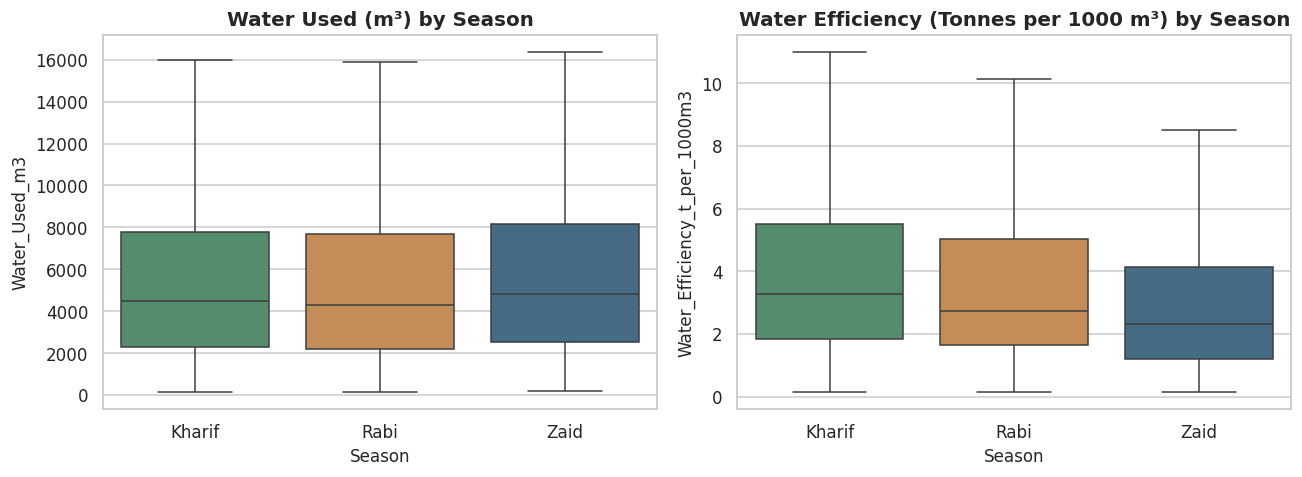

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x='Season', y='Water_Used_m3', order=SEASON_ORDER,
            palette=SEASON_COLORS, ax=axes[0], showfliers=False)
axes[0].set_title('Water Used (m³) by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,
            palette=SEASON_COLORS, ax=axes[1], showfliers=False)
axes[1].set_title('Water Efficiency (Tonnes per 1000 m³) by Season')

plt.tight_layout()
plt.show()


In [26]:
df.groupby('Season')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2).reindex(SEASON_ORDER)


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,"6,102.20",5.89
Rabi,"5,846.99",5.19
Zaid,"6,419.89",4.41


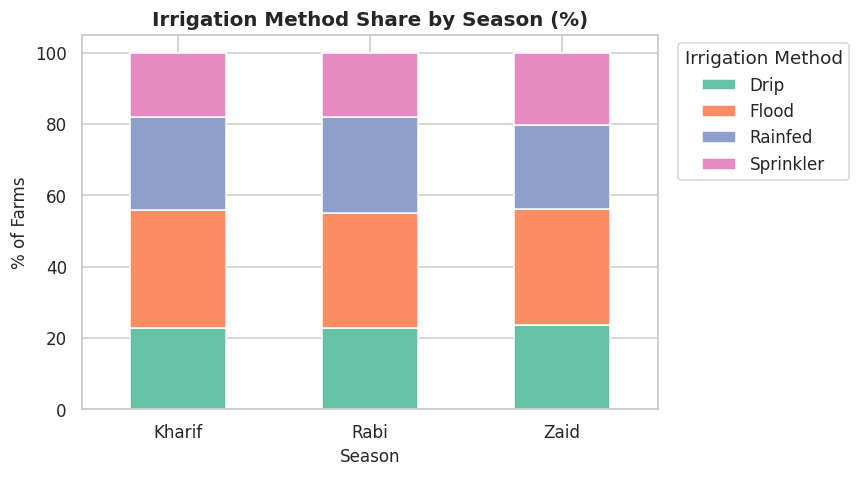

In [27]:
# Irrigation method usage share, by season
irr_share = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irr_share = irr_share.reindex(SEASON_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
irr_share.plot(kind='bar', stacked=True, ax=ax, color=sns.color_palette("Set2", 4))
ax.set_title('Irrigation Method Share by Season (%)')
ax.set_ylabel('% of Farms')
plt.xticks(rotation=0)
ax.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** Zaid has the highest average water use and the lowest average water-efficiency value among the three seasons. This indicates greater water requirement per unit of output in the observed Zaid records. on average (compensating for low rainfall) yet do not always show proportionally higher water efficiency, suggesting scope for better irrigation scheduling in the dry season. Drip and sprinkler irrigation are associated with higher water efficiency than flood or rainfed methods.

## 10. Disease & Pest Risk Analysis

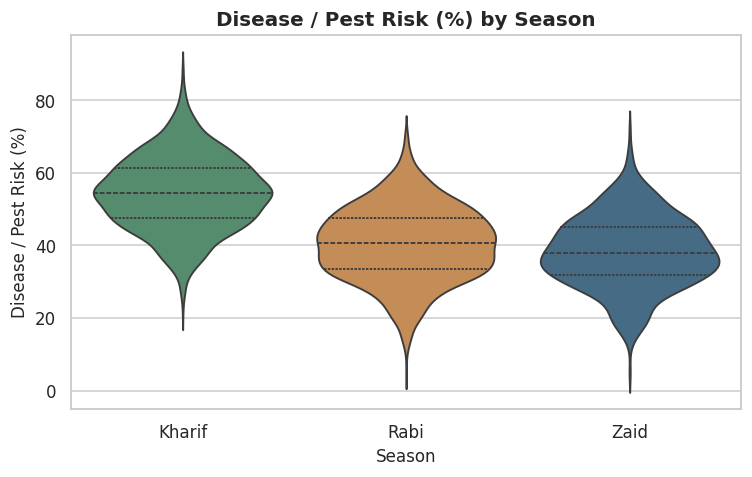

Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER,
               palette=SEASON_COLORS, ax=ax, inner='quartile')
ax.set_title('Disease / Pest Risk (%) by Season')
ax.set_ylabel('Disease / Pest Risk (%)')
plt.tight_layout()
plt.show()

df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2).reindex(SEASON_ORDER)


**Observation:** Kharif has the highest average disease/pest risk in the dataset, while Zaid has the lowest. Kharif also has higher average rainfall and humidity, so these variables move together seasonally; this is an association rather than proof of causation. in Kharif season, aligning with the higher humidity and rainfall that favour pest and fungal activity. Zaid, being hot and dry, shows the lowest average risk.

## 11. Correlation Analysis

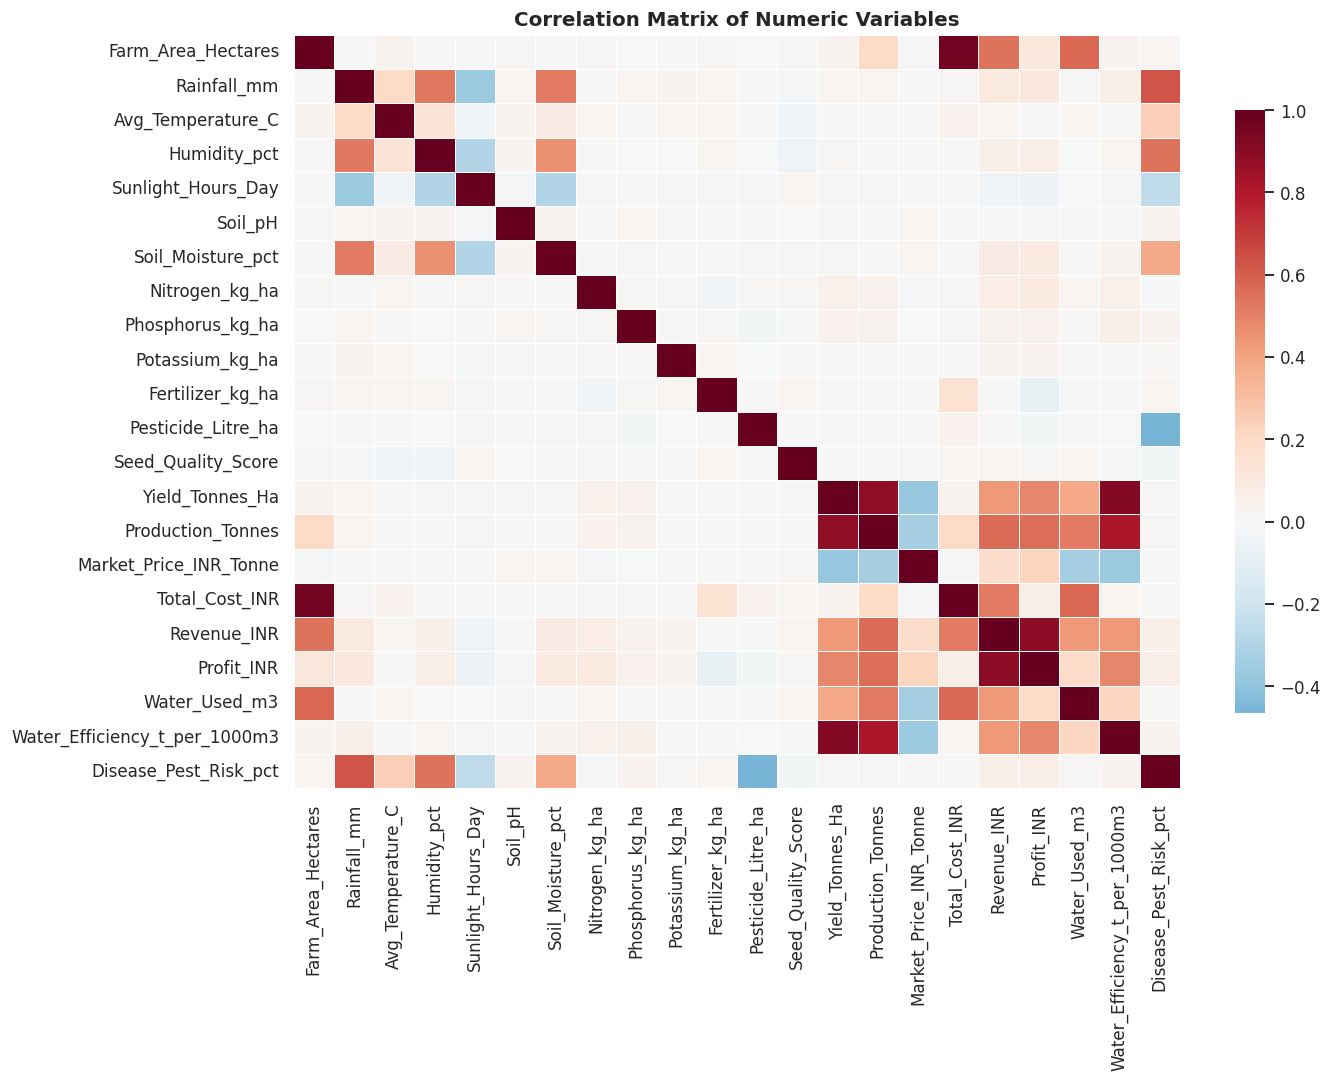

In [29]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()


In [30]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).head(8).round(3))

print("\nTop correlations with Profit_INR:")
print(corr['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False).head(8).round(3))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Market_Price_INR_Tonne          -0.38
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                     0.89
Production_Tonnes               0.55
Water_Efficiency_t_per_1000m3   0.49
Yield_Tonnes_Ha                 0.49
Market_Price_INR_Tonne          0.23
Water_Used_m3                   0.19
Farm_Area_Hectares              0.12
Rainfall_mm                     0.11
Name: Profit_INR, dtype: float64


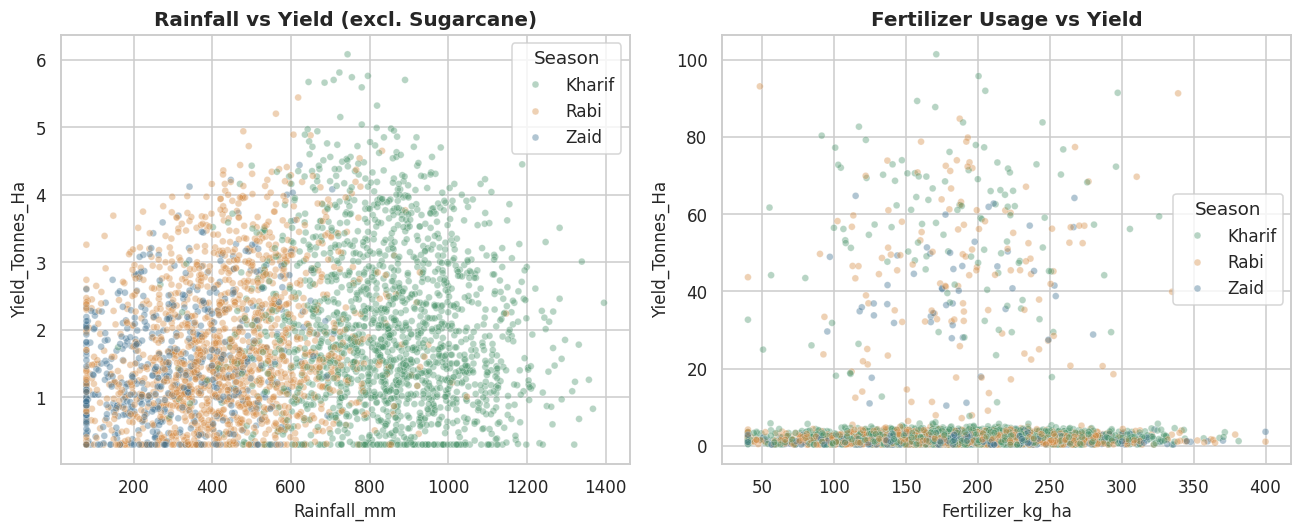

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=non_sugar, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                 palette=SEASON_COLORS, alpha=0.4, s=20, ax=axes[0])
axes[0].set_title('Rainfall vs Yield (excl. Sugarcane)')

sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season',
                 palette=SEASON_COLORS, alpha=0.4, s=20, ax=axes[1])
axes[1].set_title('Fertilizer Usage vs Yield')

plt.tight_layout()
plt.show()


**Observation:** The strongest raw correlations with Yield include mathematically related variables such as Production and Water Efficiency. These should not be treated as independent explanatory factors. Among less-direct variables, Market Price shows a negative association with Yield in the full dataset, while rainfall has only a weak raw correlation with yield. Profit is strongly associated with Revenue, which is expected because revenue is a direct component of profit. with any single environmental or input variable in isolation — this indicates agricultural performance is driven by a *combination* of factors (crop choice, season, irrigation method and market price together) rather than any one variable dominating. Market price and crop type play a bigger role in profit than raw yield alone.

## 12. Crop-wise Seasonal Patterns

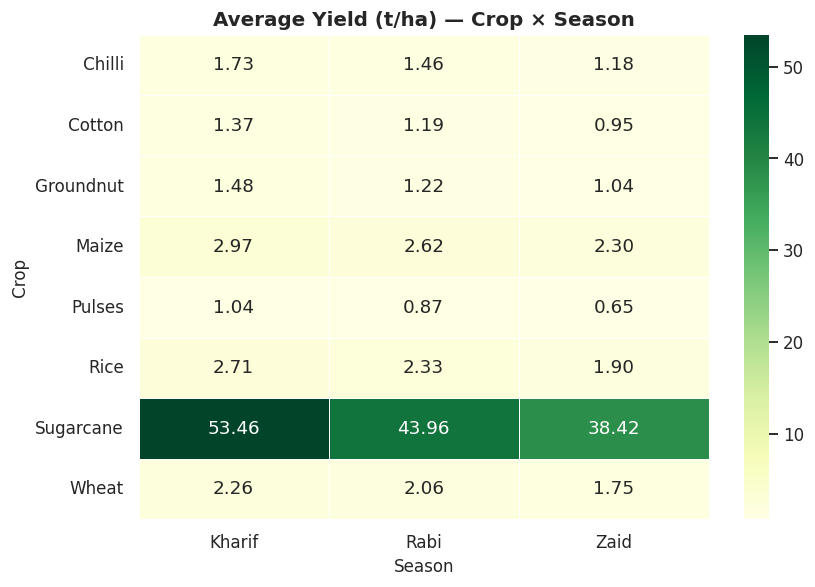

In [32]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', observed=False)
crop_season_yield = crop_season_yield[SEASON_ORDER]

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5, ax=ax)
ax.set_title('Average Yield (t/ha) — Crop × Season')
plt.tight_layout()
plt.show()


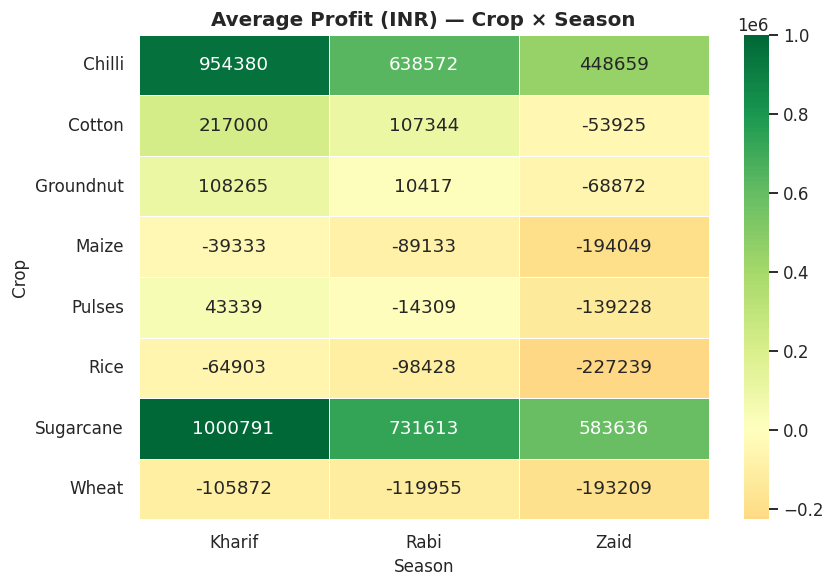

In [33]:
crop_season_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', observed=False)
crop_season_profit = crop_season_profit[SEASON_ORDER]

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Average Profit (INR) — Crop × Season')
plt.tight_layout()
plt.show()


**Observation:** Crop-level results differ across seasons. In the supplied data, every listed crop has a lower mean yield in Zaid than in Kharif, but the size of the seasonal change differs by crop. This supports crop-specific rather than one-size-fits-all seasonal interpretation. show strong seasonal preference — performing much better in one season than others, while crops like Wheat and Rice are comparatively steadier across seasons. This means seasonal recommendations should be made **per crop**, not generically for "agriculture" as a whole.

## 13. State-wise (Regional) Seasonal Patterns

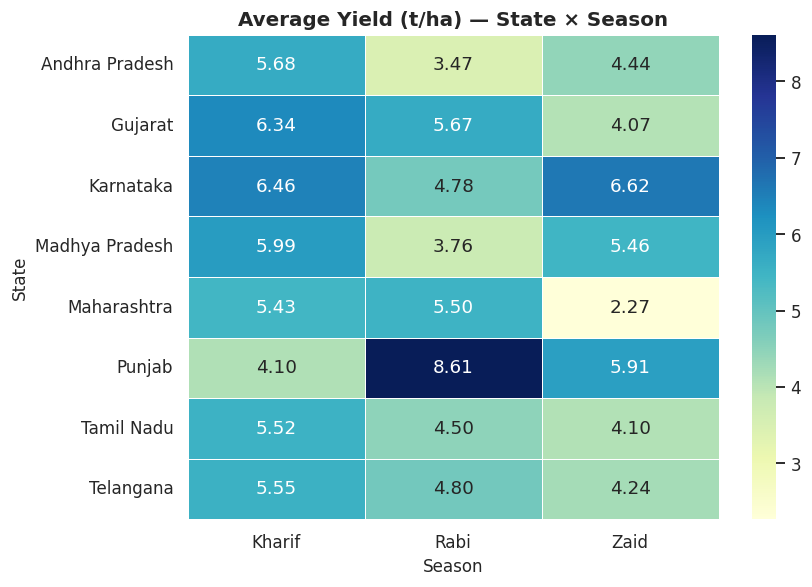

In [34]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', observed=False)
state_season_yield = state_season_yield[SEASON_ORDER]

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('Average Yield (t/ha) — State × Season')
plt.tight_layout()
plt.show()


**Observation:** Seasonal rankings are not identical across states. For example, some states show their highest observed yield in Rabi or Zaid rather than Kharif. This indicates that regional context can modify the overall seasonal pattern. (Kharif generally ahead of Zaid, for non-sugarcane crops) holds fairly consistently across most states — suggesting the seasonal effect is a broad structural pattern rather than a quirk of one or two regions. However, the absolute yield level does vary meaningfully by state, reflecting local soil/climate differences.

## 14. Irrigation Method Effectiveness by Season

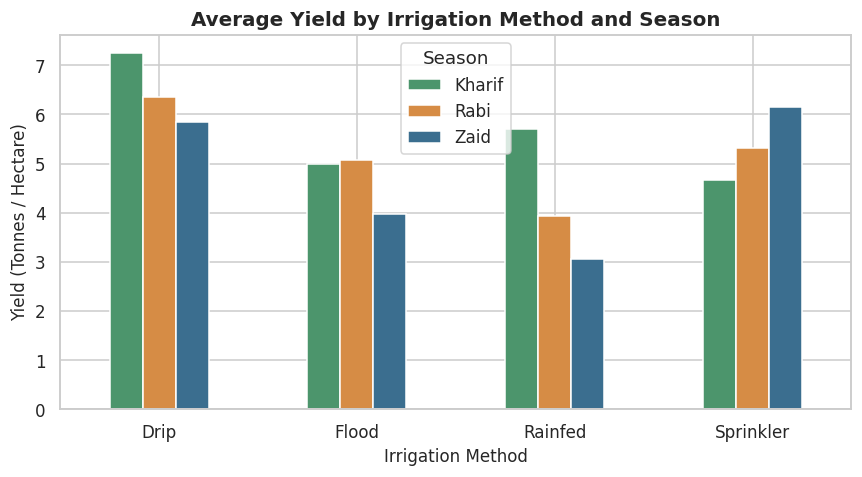

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.35,5.85
Flood,4.98,5.06,3.97
Rainfed,5.70,3.93,3.06
Sprinkler,4.67,5.31,6.14


In [35]:
# Average yield by irrigation method within each season
irr_yield = df.pivot_table(index='Irrigation_Method', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean', observed=False)
irr_yield = irr_yield.reindex(columns=SEASON_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
irr_yield.plot(kind='bar', ax=ax, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
ax.set_title('Average Yield by Irrigation Method and Season')
ax.set_ylabel('Yield (Tonnes / Hectare)')
ax.set_xlabel('Irrigation Method')
plt.xticks(rotation=0)
ax.legend(title='Season')
plt.tight_layout()
plt.show()

irr_yield.round(2)

**Observation:** Drip has the highest observed mean yield among irrigation methods in Kharif and Rabi, while Sprinkler has the highest observed mean yield in Zaid. These are group-level associations; irrigation method is not randomly assigned in the dataset, so the comparison does not prove that one method causes higher yield. over flood and rainfed methods in most seasons, and the advantage is most visible in the water-scarce Zaid season — reinforcing the water-efficiency finding from Section 9.

## 14.1 Final Seasonal Performance Dashboard

This compact dashboard brings the most important seasonal indicators together for the final project presentation.

In [36]:
# Build a presentation-ready seasonal summary
# Yield is shown for non-Sugarcane crops so the unusually large Sugarcane scale
# does not dominate the cross-crop seasonal comparison.
yield_non_sugar = non_sugar.groupby('Season', observed=False)['Yield_Tonnes_Ha'].mean().reindex(SEASON_ORDER)

dash = df.groupby('Season', observed=False).agg(
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water=('Water_Used_m3', 'mean'),
    Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).reindex(SEASON_ORDER)

dash.insert(0, 'Avg_Yield_Non_Sugarcane', yield_non_sugar)
dash['Profit_Margin_%'] = dash['Avg_Profit'] / dash['Avg_Revenue'] * 100

dash.round(2)

,Avg_Yield_Non_Sugarcane,Avg_Revenue,Avg_Profit,Avg_Water,Water_Efficiency,Disease_Risk,Profit_Margin_%
Season,,,,,,,
Kharif,2.02,"710,719.06","178,914.65","6,102.20",5.89,54.47,25.17
Rabi,1.75,"601,526.05","87,689.47","5,846.99",5.19,40.48,14.58
Zaid,1.46,"519,171.90","-24,804.82","6,419.89",4.41,38.22,-4.78


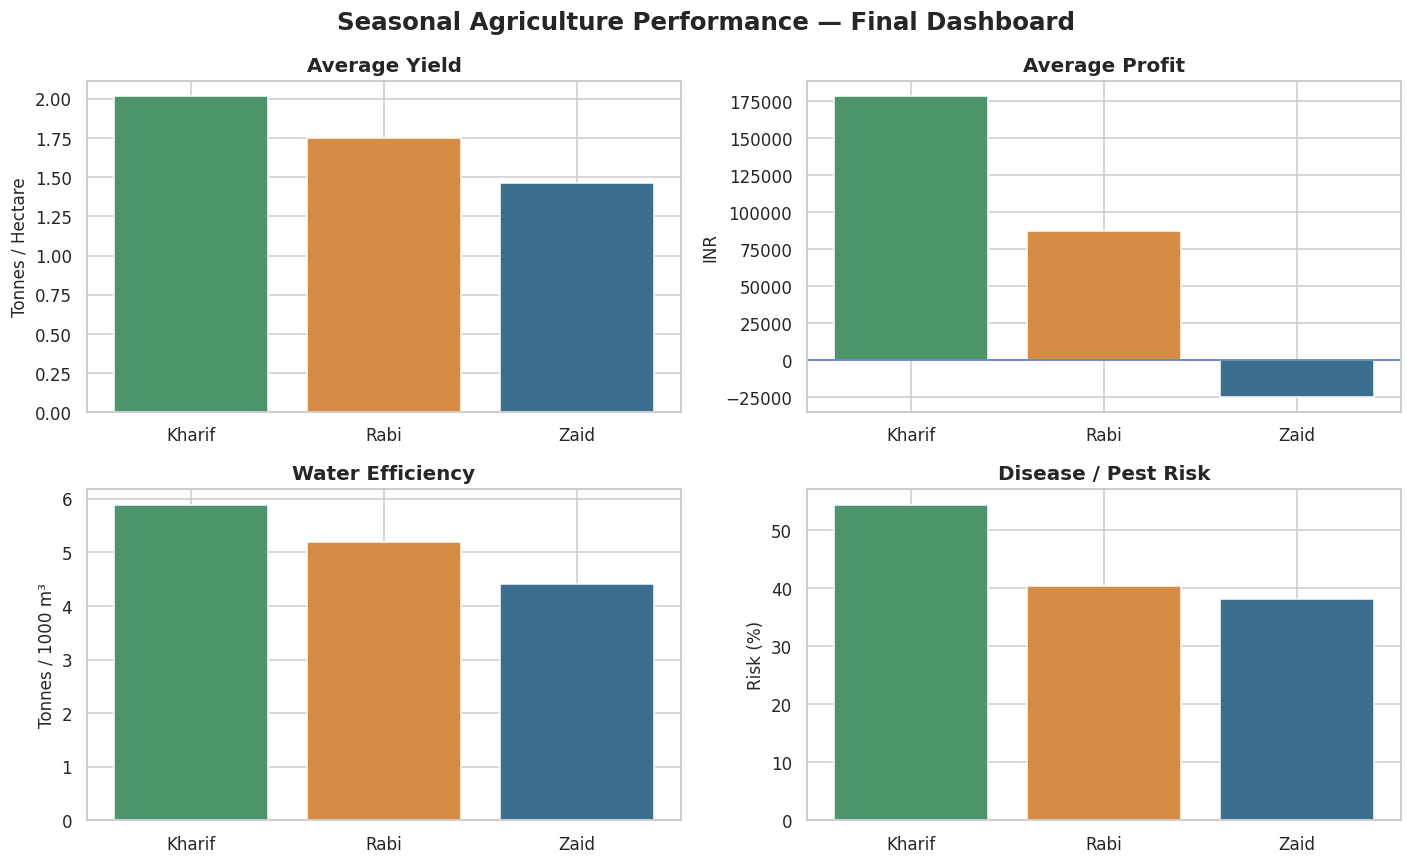

In [37]:
# Visual dashboard for screenshot / PPT use
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Yield
axes[0,0].bar(dash.index, dash['Avg_Yield_Non_Sugarcane'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[0,0].set_title('Average Yield')
axes[0,0].set_ylabel('Tonnes / Hectare')

# Profit
axes[0,1].bar(dash.index, dash['Avg_Profit'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[0,1].axhline(0, linewidth=1)
axes[0,1].set_title('Average Profit')
axes[0,1].set_ylabel('INR')

# Water efficiency
axes[1,0].bar(dash.index, dash['Water_Efficiency'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[1,0].set_title('Water Efficiency')
axes[1,0].set_ylabel('Tonnes / 1000 m³')

# Disease/pest risk
axes[1,1].bar(dash.index, dash['Disease_Risk'], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
axes[1,1].set_title('Disease / Pest Risk')
axes[1,1].set_ylabel('Risk (%)')

fig.suptitle('Seasonal Agriculture Performance — Final Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Key Insights

1. **Kharif shows the strongest overall observed performance** in the supplied dataset, including the highest average yield, revenue and profit among the three seasons.
2. **Zaid shows the greatest resource and economic pressure**: it has the highest average water use, lowest water efficiency, lowest average yield, and negative average profit.
3. **Seasonal environmental conditions differ clearly**: Kharif has the highest rainfall and humidity, while Zaid has the highest average temperature and sunlight and the lowest rainfall.
4. **Seasonal yield differences are statistically significant** in the non-Sugarcane comparison (ANOVA and Kruskal–Wallis, p < 0.05). Effect size and Tukey HSD are included to make the statistical conclusion more informative.
5. **Profitability varies by season**: Kharif has the highest mean profit margin, while Zaid has a negative mean profit margin. Negative-profit records are present in all seasons.
6. **Water efficiency is lowest in Zaid**, indicating that additional water use in the dry season does not translate into proportionally higher output in the observed records.
7. **Irrigation results vary by season**: Drip has the highest observed mean yield in Kharif and Rabi, while Sprinkler has the highest observed mean yield in Zaid. These are associations, not causal estimates.
8. **Regional patterns are not uniform**. Seasonal performance differs across states, so agricultural planning should consider local conditions rather than relying only on an overall seasonal ranking.
9. **Correlation results require care** because Production and Water Efficiency are mathematically related to Yield. The notebook therefore avoids treating those high correlations as independent causal drivers.
10. Overall, the dataset supports a **season-specific, crop-aware and resource-conscious approach** to agricultural planning.

## 16. Conclusions & Recommendations

### Conclusions

- The supplied dataset shows meaningful differences in agricultural performance across **Kharif, Rabi and Zaid** seasons.
- The observed non-Sugarcane yield difference across seasons is **statistically significant**, supported by both ANOVA and Kruskal–Wallis testing.
- Economic performance follows a different dimension from yield alone: **Kharif has the strongest average profitability, while Zaid has negative average profit** in the supplied data.
- Zaid combines the **highest average water use with the lowest water efficiency**, making resource management especially important for that season.
- Crop and state comparisons show that seasonal performance is not identical everywhere; **local and crop-specific context matters**.

### Data-driven Recommendations

1. **Improve water planning in Zaid:** prioritize efficient irrigation scheduling and compare irrigation methods using both water use and yield rather than yield alone.
2. **Use crop-season matching:** select crops based on their observed seasonal performance instead of applying a single recommendation to all crops.
3. **Strengthen Kharif risk management:** the season has the highest observed disease/pest risk, so monitoring and timely intervention should accompany its strong production performance.
4. **Focus on profitability, not yield alone:** evaluate input costs, revenue and profit margin alongside agronomic indicators when making seasonal decisions.
5. **Use regional analysis for local decisions:** state-level results differ, so recommendations should be adapted to local conditions.
6. **Collect more time-based data:** additional years, farm-level cost details and more complete environmental observations would improve future analysis and help separate seasonal effects from other factors.

> **Limitation:** This is an observational dataset. The analysis identifies patterns and associations but does not establish causal effects of rainfall, irrigation, fertilizer or other variables.